In [10]:
import pandas as pd
import altair as alt


In [11]:
weather = pd.read_csv('weatherHistory.csv')
print("First 5 rows of the dataset:")
display(weather.head())

First 5 rows of the dataset:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [15]:
import altair as alt
import pandas as pd

weather['Formatted Date'] = pd.to_datetime(weather['Formatted Date'], utc=True)

chart = alt.Chart(weather.head(5000)).mark_line().encode(
    x=alt.X('Formatted Date:T', title='Date'),
    y=alt.Y('Temperature (C):Q', title='Temperature (C)')
).properties(
    width=800,
    height=400,
    title='Temperature Time Series (Sample)'
).interactive()

chart

alt.Chart(...)

In [16]:
weather['date'] = pd.to_datetime(weather['Formatted Date'], utc=True)
weather_daily = weather.groupby(weather['date'].dt.date)['Temperature (C)'].mean().reset_index()
weather_daily.columns = ['date', 'temp']
weather_daily['date'] = pd.to_datetime(weather_daily['date'])
weather_indexed = weather_daily.set_index('date').sort_index()

temp_series = weather_indexed['temp']
display(temp_series.head())

,temp
date,
2005-12-31,0.577778
2006-01-01,4.075000
2006-01-02,5.263194
2006-01-03,2.340509
2006-01-04,2.251852


In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(temp_series)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

if result[1] > 0.05:
    print("Series is non-stationary, applying differencing...")
    temp_series_diff = temp_series.diff().dropna()
else:
    print("Series is stationary.")
    temp_series_diff = temp_series

print("First 5 rows of processed series:")
display(temp_series_diff.head())

ADF Statistic: -3.990428
p-value: 0.001461
Series is stationary.
First 5 rows of processed series:


,temp
date,
2005-12-31,0.577778
2006-01-01,4.075000
2006-01-02,5.263194
2006-01-03,2.340509
2006-01-04,2.251852


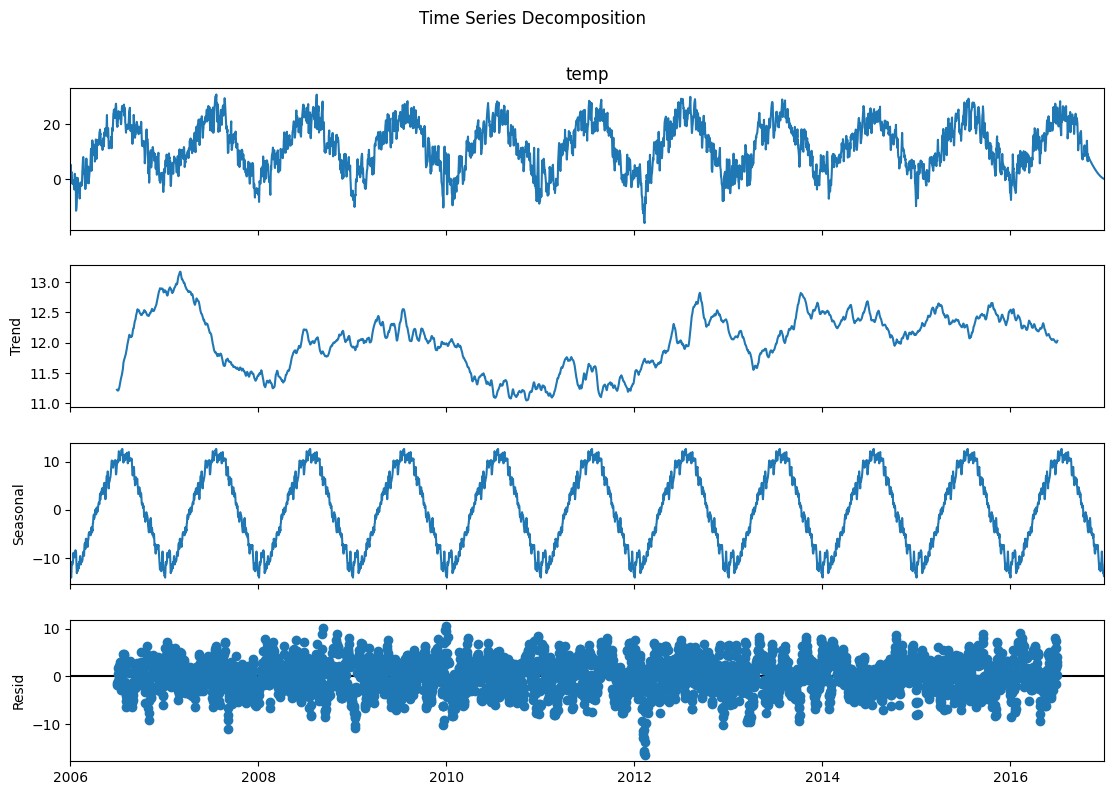

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(temp_series, model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Time Series Decomposition', y=1.02)
plt.show()

In [19]:
weather_indexed['SMA_7'] = weather_indexed['temp'].rolling(window=7).mean()
weather_indexed['SMA_30'] = weather_indexed['temp'].rolling(window=30).mean()

display(weather_indexed[['temp', 'SMA_7', 'SMA_30']].tail())

,temp,SMA_7,SMA_30
date,,,
2016-12-27,0.278009,0.475132,1.569460
2016-12-28,0.222222,0.408598,1.468434
2016-12-29,0.167824,0.345205,1.370293
2016-12-30,0.117593,0.285053,1.275116
2016-12-31,0.113527,0.234274,1.184332


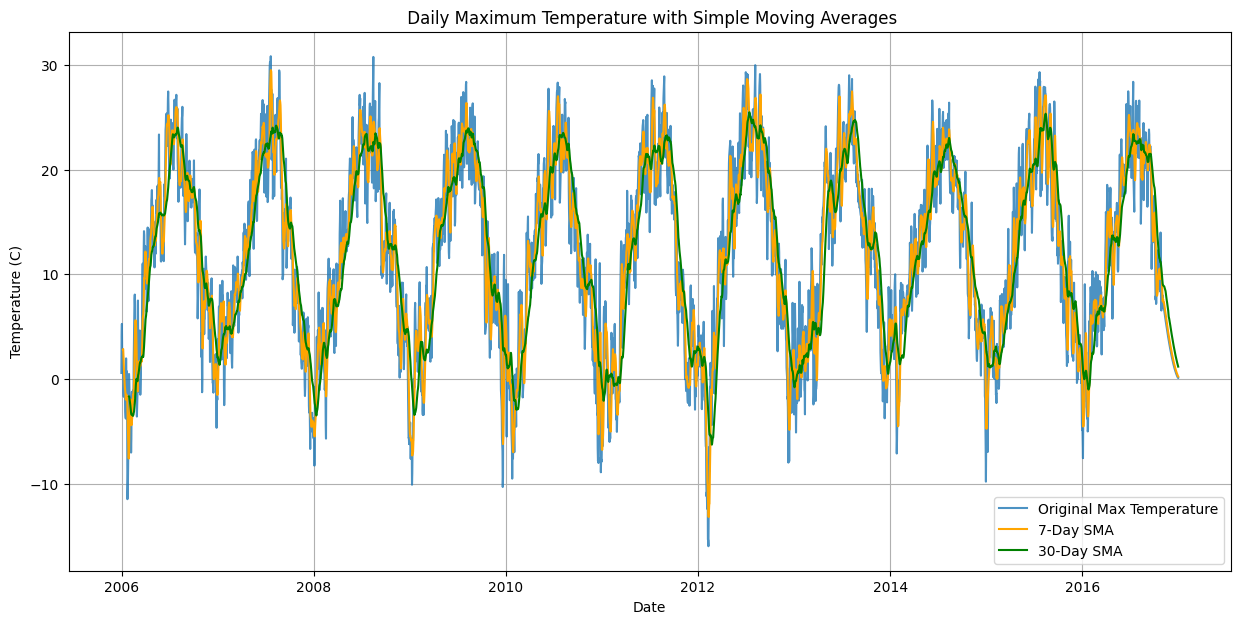

In [21]:
plt.figure(figsize=(15, 7))
plt.plot(weather_indexed['temp'], label='Original Max Temperature', alpha=0.8)
plt.plot(weather_indexed['SMA_7'], label='7-Day SMA', color='orange')
plt.plot(weather_indexed['SMA_30'], label='30-Day SMA', color='green')
plt.title(' Daily Maximum Temperature with Simple Moving Averages')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
train_data = weather_indexed['temp'][:-7]
test_data = weather_indexed['temp'][-7:]

test_dates = test_data.index

print("Training data points:", len(train_data))
print("Test data points:", len(test_data))
print("\nLast 5 training data points:")
display(train_data.tail())
print("\nTest data points (next 7 days):")
display(test_data)

Training data points: 4012
Test data points: 7

Last 5 training data points:


,temp
date,
2016-12-20,0.766898
2016-12-21,0.687963
2016-12-22,0.611574
2016-12-23,0.538657
2016-12-24,0.468981



Test data points (next 7 days):


,temp
date,
2016-12-25,0.402315
2016-12-26,0.338426
2016-12-27,0.278009
2016-12-28,0.222222
2016-12-29,0.167824
2016-12-30,0.117593
2016-12-31,0.113527


In [24]:
train_data = temp_series[:-7]
test_data = temp_series[-7:]

naive_forecast = [train_data.iloc[-1]] * 7

ma_forecast = [train_data.tail(7).mean()] * 7

forecast_df = pd.DataFrame({
    'Actual': test_data.values,
    'Naive': naive_forecast,
    'MA_7': ma_forecast
}, index=test_data.index)

display(forecast_df)

,Actual,Naive,MA_7
date,,,
2016-12-25,0.402315,0.468981,0.694213
2016-12-26,0.338426,0.468981,0.694213
2016-12-27,0.278009,0.468981,0.694213
2016-12-28,0.222222,0.468981,0.694213
2016-12-29,0.167824,0.468981,0.694213
2016-12-30,0.117593,0.468981,0.694213
2016-12-31,0.113527,0.468981,0.694213


MAE Naive: 0.23
MAE Moving Average: 0.46


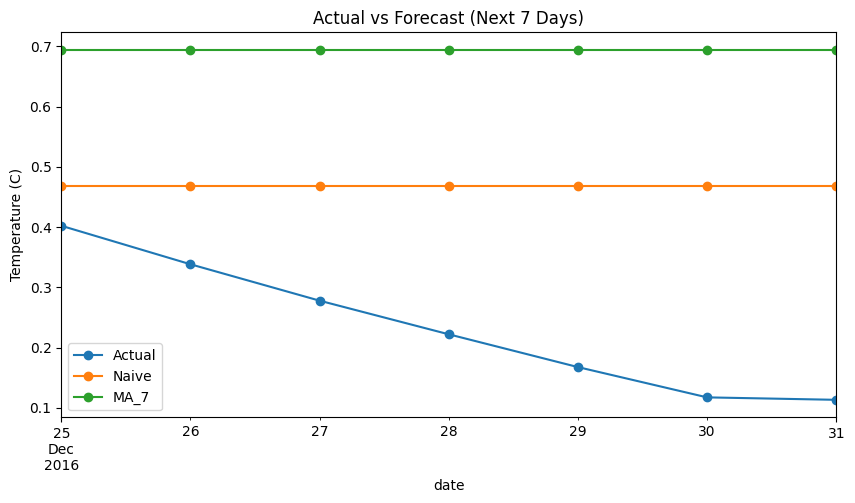

In [25]:
from sklearn.metrics import mean_absolute_error

mae_naive = mean_absolute_error(forecast_df['Actual'], forecast_df['Naive'])
mae_ma = mean_absolute_error(forecast_df['Actual'], forecast_df['MA_7'])

print(f"MAE Naive: {mae_naive:.2f}")
print(f"MAE Moving Average: {mae_ma:.2f}")

forecast_df.plot(figsize=(10, 5), marker='o')
plt.title('Actual vs Forecast (Next 7 Days)')
plt.ylabel('Temperature (C)')
plt.show()

In [30]:
from statsmodels.tsa.stattools import adfuller

temp_series = weather_daily.set_index('date')['temp']

result = adfuller(temp_series)

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nThe series is stationary (p-value <= 0.05).")
else:
    print("\nThe series is non-stationary (p-value > 0.05).")

ADF Statistic: -3.990428
p-value: 0.001461
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567

The series is stationary (p-value <= 0.05).
